<a href="https://colab.research.google.com/github/HamzaEric/facial-expression-autoencoders/blob/main/Notebooks/Anomaly_Detection_%26_Denoising_Autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Reconstruction error**


An autoencoder takes an original input image $x$, compresses it into a latent representation $z$, and then reconstructs the image as $\hat{x}$.

```text
Original image (x)
       ↓
    Encoder
       ↓
   Latent (z)
       ↓
    Decoder
       ↓
Reconstructed image (x̂)
```

The **reconstruction error** measures how different the original image is from the reconstructed image.

For a single image:

$$
RE = \|\hat{x} - x\|^2
$$

Where:

* $x$ = original input image
* $\hat{x}$ = reconstructed image
* $RE$ = reconstruction error

A larger difference between $x$ and $\hat{x}$ produces a larger reconstruction error.

### Mean Squared Reconstruction Error

The reconstruction error can also be calculated as the average squared difference across all pixels:

$$
err(x,\hat{x})
=
\frac{1}{HW}
\sum_{p=1}^{HW}
(x_p-\hat{x}_p)^2
$$

For FER2013:

$$
H = 48,\qquad W = 48
$$

Therefore:

$$
HW = 48 \times 48 = 2304
$$

So:

$$
err(x,\hat{x})
=
\frac{1}{2304}
\sum_{p=1}^{2304}
(x_p-\hat{x}_p)^2
$$

This is essentially **Mean Squared Error (MSE)**.

### PyTorch Implementation

```python
reconstruction_error = torch.mean((x - x_hat) ** 2)
```

Here:

```text
x      → original image
x_hat  → reconstructed image
```

### Key Idea

> **Reconstruction error tells us how well the autoencoder was able to reconstruct the original input.**

* **Low reconstruction error** → reconstruction is close to the original.
* **High reconstruction error** → reconstruction is significantly different from the original.

This is particularly useful for **anomaly detection**, where unusual inputs may produce higher reconstruction errors.


In [1]:
import torch
import torch.nn as nn
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
from math import inf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

In [2]:
class FC_Autoencoder(nn.Module):
    def __init__(self):
        super(FC_Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(48 * 48, 512),
            nn.ReLU(),
            nn.Linear(512, 128)
        )
        self.decoder = nn.Sequential(
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, 48 * 48),
            nn.Sigmoid()   # constrain outputs to [0, 1]
        )

    def forward(self, x):
        x = x.view(-1, 48 * 48)
        z = self.encoder(x)
        out = self.decoder(z)
        out = out.view(-1, 1, 48, 48)
        return out

# Initialize model
model = FC_Autoencoder()

# trained weights
model.load_state_dict(torch.load("/content/drive/MyDrive/ae_model.pth", map_location='cpu'))

# Confirm input–output shape consistency
dummy_input = torch.randn(1, 1, 48, 48)
dummy_output = model(dummy_input)
print(f"Input shape: {dummy_input.shape}, Output shape: {dummy_output.shape}")

Input shape: torch.Size([1, 1, 48, 48]), Output shape: torch.Size([1, 1, 48, 48])


### **Anomaly Detection – Evaluation & Visualization**

We will now **quantify** and **visualize** the anomaly effect.  
The expectation is straightforward: when the model sees images that come from emotions it was **trained on** (known), it reconstructs them well, leading to **low reconstruction error**.  
When it sees **unseen** emotions (unknown), it struggles, producing **higher reconstruction error**.

> In other words, reconstruction error acts as an indicator of **novelty**: the autoencoder “knows” what it has seen before.

**Compute Reconstruction Errors (Known vs Unknown)**

We will compute per-image reconstruction error as the mean squared difference between $x$ and $\hat{x}$:
$$
\text{err}(x,\hat{x}) = \frac{1}{HW}\sum_{p}(x_p - \hat{x}_p)^2
$$
where $H=W=48$ for FER2013 faces.


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

FC_Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=2304, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=128, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=2304, bias=True)
    (3): Sigmoid()
  )
)

In [4]:
try:
    X, y
except NameError:
    data = np.load("/content/drive/MyDrive/fer2013_full.npz")
    X, y = data["X"], data["y"]

known_labels = {0, 3, 4, 5, 6}   # angry, happy, sad, surprise, neutral
unknown_labels = {1, 2}          # disgust, fear

# Build known/unknown tensors
idx_known_eval = np.isin(y, list(known_labels))
idx_unknown_eval = np.isin(y, list(unknown_labels))

X_known_eval = torch.tensor(X[idx_known_eval], dtype=torch.float32).unsqueeze(1)
X_unknown_eval = torch.tensor(X[idx_unknown_eval], dtype=torch.float32).unsqueeze(1)

def reconstruction_errors(batch_tensor):
    """
    Compute per-image MSE reconstruction error in [0, 1] space.
    Returns a 1D numpy array of length N.
    """
    errs = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(batch_tensor), 256):
            xb = batch_tensor[i:i+256].to(device)
            xhat = model(xb)
            # Per-image MSE over HxW (not batch-averaged)
            e = (xhat - xb).pow(2).mean(dim=(1,2,3))  # (N,)
            errs.append(e.cpu().numpy())
    return np.concatenate(errs, axis=0)

errs_known = reconstruction_errors(X_known_eval)
errs_unknown = reconstruction_errors(X_unknown_eval)

print("Known eval count  :", len(errs_known))
print("Unknown eval count:", len(errs_unknown))
print("Known error stats :", np.mean(errs_known), np.median(errs_known))
print("Unknown error stats:", np.mean(errs_unknown), np.median(errs_unknown))


Known eval count  : 30219
Unknown eval count: 5668
Known error stats : 0.29527554 0.2868694
Unknown error stats: 0.2727242 0.26263496


**Histograms of Reconstruction Errors**

We will visualize the error distributions for known vs unknown samples.</br>
If the anomaly effect is present, the unknown distribution will be shifted to the right (higher errors).

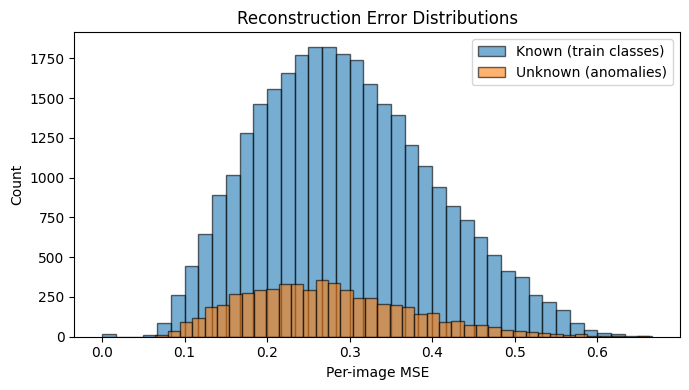

In [5]:
plt.figure(figsize=(7, 4))
bins = 40
plt.hist(errs_known, bins=bins, alpha=0.6, label="Known (train classes)", edgecolor="black")
plt.hist(errs_unknown, bins=bins, alpha=0.6, label="Unknown (anomalies)", edgecolor="black")
plt.title("Reconstruction Error Distributions")
plt.xlabel("Per-image MSE")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

95th percentile threshold (known errors): 0.48722007870674133
ROC AUC (known vs unknown): 0.43748876555648586


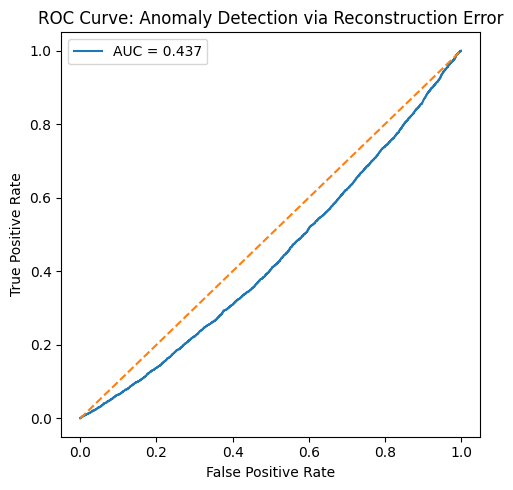

In [6]:
# Simple threshold: 95th percentile of known errors
thr = np.percentile(errs_known, 95)
print("95th percentile threshold (known errors):", float(thr))

# Build labels and scores for ROC AUC
y_true = np.concatenate([np.zeros_like(errs_known), np.ones_like(errs_unknown)])  # 0=known, 1=unknown
y_score = np.concatenate([errs_known, errs_unknown])

auc = roc_auc_score(y_true, y_score)
print("ROC AUC (known vs unknown):", float(auc))

# Optional: ROC curve points
fpr, tpr, _ = roc_curve(y_true, y_score)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Anomaly Detection via Reconstruction Error")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
def _to_nchw_float32(x):
    """
    Accepts numpy or torch arrays in shape:
      - (N, 48, 48)  or
      - (N, 1, 48, 48)
    Returns torch.FloatTensor on model.device with shape (N, 1, 48, 48).
    """
    device = next(model.parameters()).device
    # If torch tensor, move to CPU for shape checks
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()

    x = np.asarray(x)
    if x.ndim == 3 and x.shape[1:] == (48, 48):
        x = x[:, None, :, :]  # add channel dim -> (N,1,48,48)
    elif x.ndim == 4 and x.shape[1:] == (1, 48, 48):
        pass  # already (N,1,48,48)
    else:
        raise ValueError(f"Expected (N,48,48) or (N,1,48,48), got {x.shape}")

    xt = torch.tensor(x, dtype=torch.float32, device=device)
    return xt

def recon_pairs(XA, title_left, XB, title_right, n=5):
    """
    Robust side-by-side original vs reconstruction for two groups.
    Accepts XA/XB as numpy arrays or torch tensors with shape (N,48,48) or (N,1,48,48).
    """
    n = min(n, len(XA), len(XB))
    model.eval()

    A = _to_nchw_float32(XA[:n])
    B = _to_nchw_float32(XB[:n])

    with torch.no_grad():
        Ah = model(A).cpu().numpy()
        Bh = model(B).cpu().numpy()
        A  = A.cpu().numpy()
        B  = B.cpu().numpy()

    fig, axes = plt.subplots(n, 4, figsize=(8, 2*n))
    for i in range(n):
        axes[i, 0].imshow(A[i, 0], cmap="gray", vmin=0.0, vmax=1.0)
        axes[i, 0].set_title(f"{title_left} (orig)", fontsize=9); axes[i, 0].axis("off")

        axes[i, 1].imshow(Ah[i, 0], cmap="gray", vmin=0.0, vmax=1.0)
        axes[i, 1].set_title(f"{title_left} (recon)", fontsize=9); axes[i, 1].axis("off")

        axes[i, 2].imshow(B[i, 0], cmap="gray", vmin=0.0, vmax=1.0)
        axes[i, 2].set_title(f"{title_right} (orig)", fontsize=9); axes[i, 2].axis("off")

        axes[i, 3].imshow(Bh[i, 0], cmap="gray", vmin=0.0, vmax=1.0)
        axes[i, 3].set_title(f"{title_right} (recon)", fontsize=9); axes[i, 3].axis("off")

    plt.tight_layout()
    plt.show()


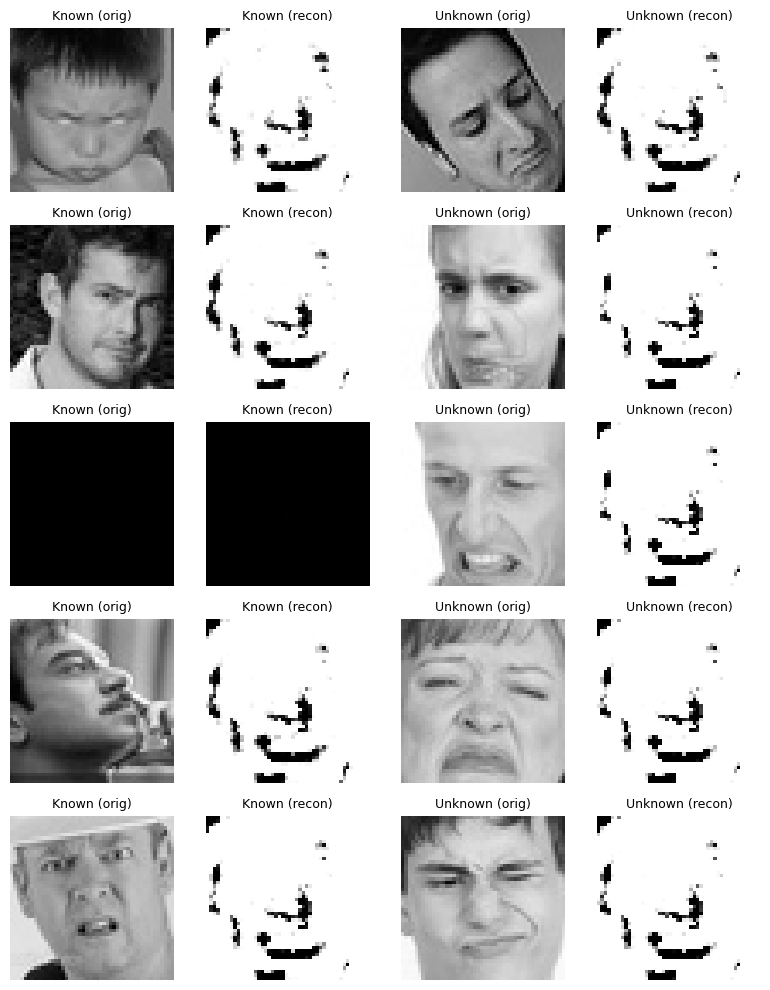

In [8]:
recon_pairs(X_known_eval, "Known", X_unknown_eval, "Unknown", n=5)

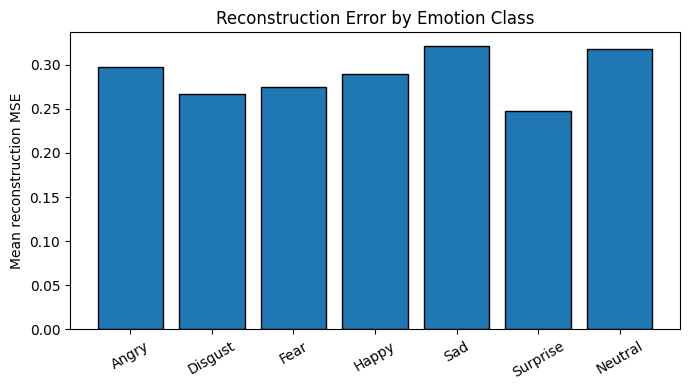

/tmp/ipykernel_500/1274298641.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([d for d in data_for_box if len(d)>0], labels=[l for l,d in zip(labels, data_for_box) if len(d)>0], showfliers=False)


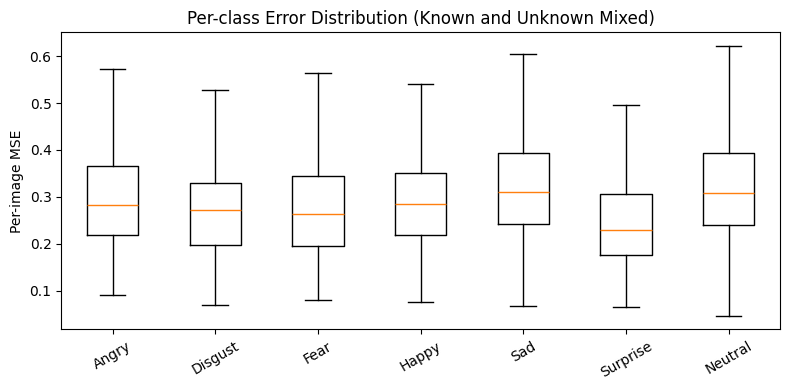

In [9]:

labels = ["Angry","Disgust","Fear","Happy","Sad","Surprise","Neutral"]

def per_class_errors(X_all, y_all, max_per_class=400):
    errs_by_cls = {}
    for lbl in range(7):
        idx = np.where(y_all == lbl)[0]
        if len(idx) == 0:
            continue
        if len(idx) > max_per_class:
            idx = np.random.choice(idx, size=max_per_class, replace=False)
        errs = reconstruction_errors(torch.tensor(X_all[idx], dtype=torch.float32).unsqueeze(1))
        errs_by_cls[lbl] = errs
    return errs_by_cls

errs_cls = per_class_errors(X, y, max_per_class=400)

# Bar plot of class-wise means
means = [errs_cls[k].mean() if k in errs_cls else np.nan for k in range(7)]
plt.figure(figsize=(7,4))
plt.bar(labels, means, edgecolor="black")
plt.xticks(rotation=30)
plt.ylabel("Mean reconstruction MSE")
plt.title("Reconstruction Error by Emotion Class")
plt.tight_layout()
plt.show()

# Optional: box plot to show spread
data_for_box = [errs_cls.get(k, np.array([])) for k in range(7)]
plt.figure(figsize=(8,4))
plt.boxplot([d for d in data_for_box if len(d)>0], labels=[l for l,d in zip(labels, data_for_box) if len(d)>0], showfliers=False)
plt.xticks(rotation=30)
plt.ylabel("Per-image MSE")
plt.title("Per-class Error Distribution (Known and Unknown Mixed)")
plt.tight_layout()
plt.show()

# Training for Anomaly Detection

Our goal is to train an autoencoder only on **common emotions** so that it becomes familiar with those patterns. Later, we will test it on **rare or unseen emotions** and compare reconstruction errors.

- **Known emotions for training:** happy, neutral, sad, surprise, angry  
- **Unknown emotions for testing (anomalies):** fear, disgust

We ensure that the training subset is **balanced** across the known classes so the model does not overfit to any single expression style.

**Data Preparation (filter, balance, split)**

**FER2013 label convention:**  
0: Angry, 1: Disgust, 2: Fear, 3: Happy, 4: Sad, 5: Surprise, 6: Neutral

- Known (train): {0, 3, 4, 5, 6}  
- Unknown (anomalies at test time): {1, 2}

In [10]:
try:
    X, y
except NameError:
    data = np.load("/content/drive/MyDrive/fer2013_full.npz")
    X, y = data["X"], data["y"]

known_labels = {0, 3, 4, 5, 6}    # angry, happy, sad, surprise, neutral
unknown_labels = {1, 2}           # disgust, fear

# Filter known subset
mask_known = np.isin(y, list(known_labels))
X_known, y_known = X[mask_known], y[mask_known]


counts = Counter(y_known.tolist())
min_count = min(counts.values())
idx_balanced = []

# collect min_count indices per class
for lbl in sorted(known_labels):
    idx_lbl = np.where(y_known == lbl)[0]
    choose = np.random.choice(idx_lbl, size=min_count, replace=False)
    idx_balanced.append(choose)

idx_balanced = np.concatenate(idx_balanced, axis=0)
np.random.shuffle(idx_balanced)

X_known_bal = X_known[idx_balanced]
y_known_bal = y_known[idx_balanced]

print("Balanced known class counts:",
      Counter(y_known_bal.tolist()))
print("X_known_bal shape:", X_known_bal.shape)


Balanced known class counts: Counter({5: 4002, 0: 4002, 4: 4002, 3: 4002, 6: 4002})
X_known_bal shape: (20010, 48, 48)


In [11]:
Xk_train, Xk_test, yk_train, yk_test = train_test_split(
    X_known_bal, y_known_bal, test_size=0.15, random_state=42, stratify=y_known_bal
)

# Convert to torch tensors with channel dimension (N, 1, 48, 48)
Xk_train_t = torch.tensor(Xk_train, dtype=torch.float32).unsqueeze(1)
Xk_test_t  = torch.tensor(Xk_test,  dtype=torch.float32).unsqueeze(1)

train_ds = TensorDataset(Xk_train_t)   # labels not used for AE training
test_ds  = TensorDataset(Xk_test_t)

BATCH_SIZE = 128
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

len(train_loader), len(test_loader)

(133, 24)

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [13]:
EPOCHS = 100
best_test = inf
best_state = None

for epoch in range(1, EPOCHS + 1):
    # ----- Train -----
    model.train()
    train_sum = 0.0
    for (xb,) in train_loader:
        xb = xb.to(device)
        optimizer.zero_grad()
        xhat = model(xb)
        loss = criterion(xhat, xb)
        loss.backward()
        optimizer.step()
        train_sum += loss.item() * xb.size(0)
    train_avg = train_sum / len(train_ds)

    # ----- Eval on held-out known data -----
    model.eval()
    test_sum = 0.0
    with torch.no_grad():
        for (xb,) in test_loader:
            xb = xb.to(device)
            xhat = model(xb)
            loss = criterion(xhat, xb)
            test_sum += loss.item() * xb.size(0)
    test_avg = test_sum / len(test_ds)

    print(f"Epoch {epoch:02d} | train MSE: {train_avg:.5f} | test MSE: {test_avg:.5f}")

    if test_avg < best_test:
        best_test = test_avg
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}


if best_state is not None:
    model.load_state_dict(best_state)


Epoch 01 | train MSE: 0.03009 | test MSE: 0.01471
Epoch 02 | train MSE: 0.01314 | test MSE: 0.01230
Epoch 03 | train MSE: 0.01137 | test MSE: 0.01109
Epoch 04 | train MSE: 0.01058 | test MSE: 0.01037
Epoch 05 | train MSE: 0.01015 | test MSE: 0.01004
Epoch 06 | train MSE: 0.00979 | test MSE: 0.00999
Epoch 07 | train MSE: 0.00952 | test MSE: 0.00960
Epoch 08 | train MSE: 0.00927 | test MSE: 0.00930
Epoch 09 | train MSE: 0.00917 | test MSE: 0.00927
Epoch 10 | train MSE: 0.00901 | test MSE: 0.00912
Epoch 11 | train MSE: 0.00890 | test MSE: 0.00897
Epoch 12 | train MSE: 0.00880 | test MSE: 0.00911
Epoch 13 | train MSE: 0.00877 | test MSE: 0.00899
Epoch 14 | train MSE: 0.00870 | test MSE: 0.00884
Epoch 15 | train MSE: 0.00862 | test MSE: 0.00879
Epoch 16 | train MSE: 0.00860 | test MSE: 0.00880
Epoch 17 | train MSE: 0.00854 | test MSE: 0.00879
Epoch 18 | train MSE: 0.00851 | test MSE: 0.00870
Epoch 19 | train MSE: 0.00851 | test MSE: 0.00869
Epoch 20 | train MSE: 0.00843 | test MSE: 0.00868


In [14]:
try:
    X, y
except NameError:
    data = np.load("/content/drive/MyDrive/fer2013_full.npz")
    X, y = data["X"], data["y"]

known_labels = {0, 3, 4, 5, 6}   # angry, happy, sad, surprise, neutral
unknown_labels = {1, 2}          # disgust, fear

# Build known/unknown tensors
idx_known_eval = np.isin(y, list(known_labels))
idx_unknown_eval = np.isin(y, list(unknown_labels))

X_known_eval = torch.tensor(X[idx_known_eval], dtype=torch.float32).unsqueeze(1)
X_unknown_eval = torch.tensor(X[idx_unknown_eval], dtype=torch.float32).unsqueeze(1)

def reconstruction_errors(batch_tensor):
    """
    Compute per-image MSE reconstruction error in [0, 1] space.
    Returns a 1D numpy array of length N.
    """
    errs = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(batch_tensor), 256):
            xb = batch_tensor[i:i+256].to(device)
            xhat = model(xb)
            # Per-image MSE over HxW (not batch-averaged)
            e = (xhat - xb).pow(2).mean(dim=(1,2,3))  # (N,)
            errs.append(e.cpu().numpy())
    return np.concatenate(errs, axis=0)

errs_known = reconstruction_errors(X_known_eval)
errs_unknown = reconstruction_errors(X_unknown_eval)

print("Known eval count  :", len(errs_known))
print("Unknown eval count:", len(errs_unknown))
print("Known error stats :", np.mean(errs_known), np.median(errs_known))
print("Unknown error stats:", np.mean(errs_unknown), np.median(errs_unknown))


Known eval count  : 30219
Unknown eval count: 5668
Known error stats : 0.0071510496 0.0065099914
Unknown error stats: 0.008425117 0.007392497


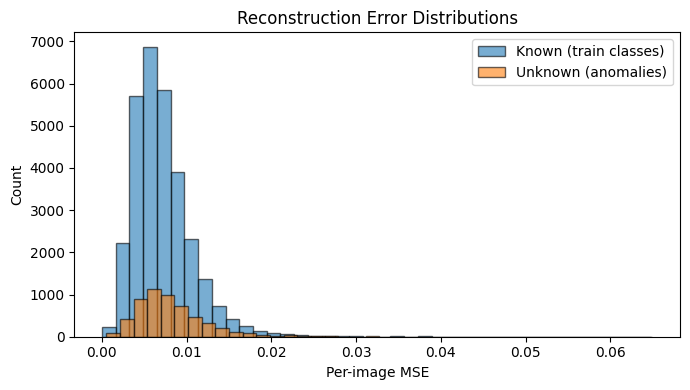

In [15]:
plt.figure(figsize=(7, 4))
bins = 40
plt.hist(errs_known, bins=bins, alpha=0.6, label="Known (train classes)", edgecolor="black")
plt.hist(errs_unknown, bins=bins, alpha=0.6, label="Unknown (anomalies)", edgecolor="black")
plt.title("Reconstruction Error Distributions")
plt.xlabel("Per-image MSE")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

95th percentile threshold (known errors): 0.01352670881897211
ROC AUC (known vs unknown): 0.5786173366791278


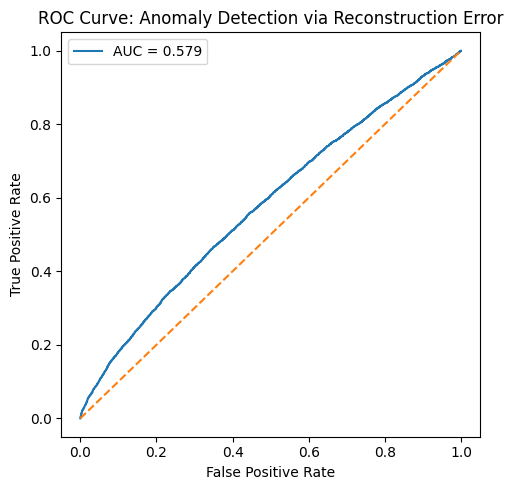

In [16]:
# Simple threshold: 95th percentile of known errors
thr = np.percentile(errs_known, 95)
print("95th percentile threshold (known errors):", float(thr))

# Build labels and scores for ROC AUC
y_true = np.concatenate([np.zeros_like(errs_known), np.ones_like(errs_unknown)])  # 0=known, 1=unknown
y_score = np.concatenate([errs_known, errs_unknown])

auc = roc_auc_score(y_true, y_score)
print("ROC AUC (known vs unknown):", float(auc))

# Optional: ROC curve points
fpr, tpr, _ = roc_curve(y_true, y_score)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Anomaly Detection via Reconstruction Error")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
def _to_nchw_float32(x):
    """
    Accepts numpy or torch arrays in shape:
      - (N, 48, 48)  or
      - (N, 1, 48, 48)
    Returns torch.FloatTensor on model.device with shape (N, 1, 48, 48).
    """
    device = next(model.parameters()).device
    # If torch tensor, move to CPU for shape checks
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()

    x = np.asarray(x)
    if x.ndim == 3 and x.shape[1:] == (48, 48):
        x = x[:, None, :, :]  # add channel dim -> (N,1,48,48)
    elif x.ndim == 4 and x.shape[1:] == (1, 48, 48):
        pass  # already (N,1,48,48)
    else:
        raise ValueError(f"Expected (N,48,48) or (N,1,48,48), got {x.shape}")

    xt = torch.tensor(x, dtype=torch.float32, device=device)
    return xt

def recon_pairs(XA, title_left, XB, title_right, n=5):
    """
    Robust side-by-side original vs reconstruction for two groups.
    Accepts XA/XB as numpy arrays or torch tensors with shape (N,48,48) or (N,1,48,48).
    """
    n = min(n, len(XA), len(XB))
    model.eval()

    A = _to_nchw_float32(XA[:n])
    B = _to_nchw_float32(XB[:n])

    with torch.no_grad():
        Ah = model(A).cpu().numpy()
        Bh = model(B).cpu().numpy()
        A  = A.cpu().numpy()
        B  = B.cpu().numpy()

    fig, axes = plt.subplots(n, 4, figsize=(8, 2*n))
    for i in range(n):
        axes[i, 0].imshow(A[i, 0], cmap="gray", vmin=0.0, vmax=1.0)
        axes[i, 0].set_title(f"{title_left} (orig)", fontsize=9); axes[i, 0].axis("off")

        axes[i, 1].imshow(Ah[i, 0], cmap="gray", vmin=0.0, vmax=1.0)
        axes[i, 1].set_title(f"{title_left} (recon)", fontsize=9); axes[i, 1].axis("off")

        axes[i, 2].imshow(B[i, 0], cmap="gray", vmin=0.0, vmax=1.0)
        axes[i, 2].set_title(f"{title_right} (orig)", fontsize=9); axes[i, 2].axis("off")

        axes[i, 3].imshow(Bh[i, 0], cmap="gray", vmin=0.0, vmax=1.0)
        axes[i, 3].set_title(f"{title_right} (recon)", fontsize=9); axes[i, 3].axis("off")

    plt.tight_layout()
    plt.show()


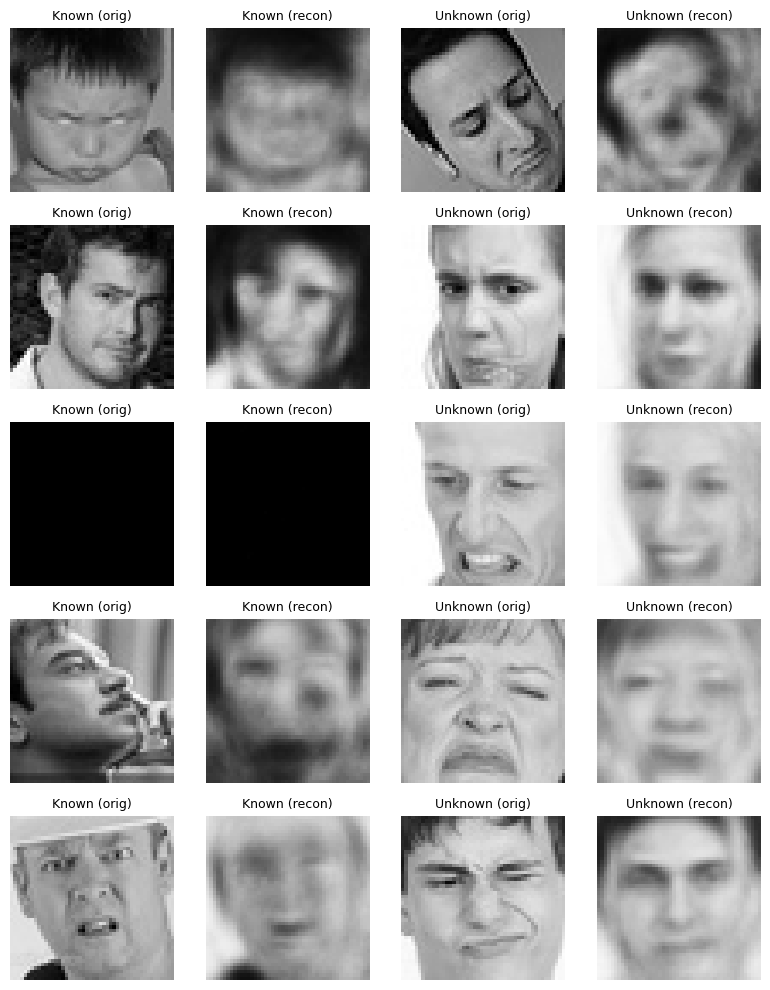

In [18]:
recon_pairs(X_known_eval, "Known", X_unknown_eval, "Unknown", n=5)

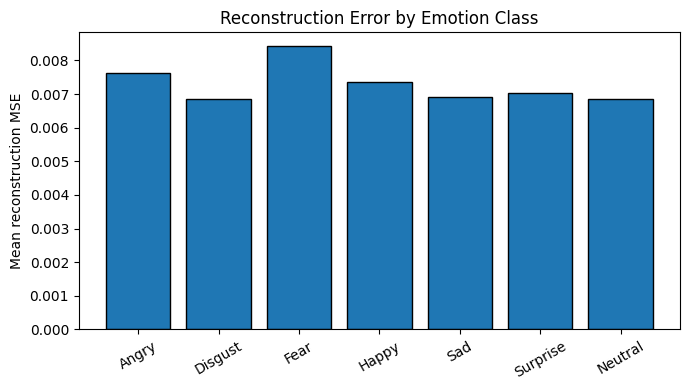

/tmp/ipykernel_500/635428496.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([d for d in data_for_box if len(d)>0], labels=[l for l,d in zip(labels, data_for_box) if len(d)>0], showfliers=False)


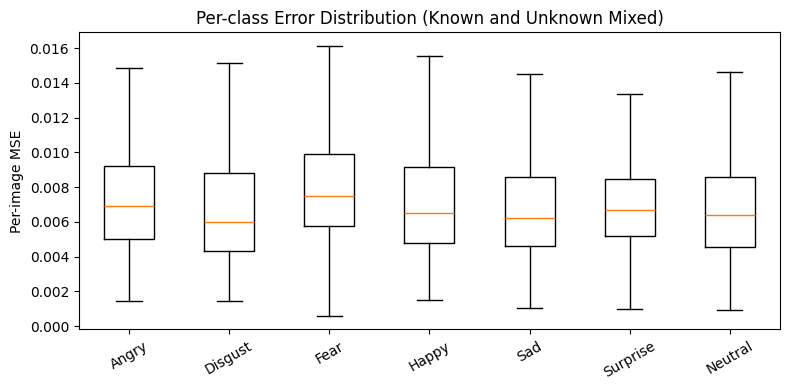

In [19]:
labels = ["Angry","Disgust","Fear","Happy","Sad","Surprise","Neutral"]

def per_class_errors(X_all, y_all, max_per_class=400):
    errs_by_cls = {}
    for lbl in range(7):
        idx = np.where(y_all == lbl)[0]
        if len(idx) == 0:
            continue
        if len(idx) > max_per_class:
            idx = np.random.choice(idx, size=max_per_class, replace=False)
        errs = reconstruction_errors(torch.tensor(X_all[idx], dtype=torch.float32).unsqueeze(1))
        errs_by_cls[lbl] = errs
    return errs_by_cls

errs_cls = per_class_errors(X, y, max_per_class=400)

# Bar plot of class-wise means
means = [errs_cls[k].mean() if k in errs_cls else np.nan for k in range(7)]
plt.figure(figsize=(7,4))
plt.bar(labels, means, edgecolor="black")
plt.xticks(rotation=30)
plt.ylabel("Mean reconstruction MSE")
plt.title("Reconstruction Error by Emotion Class")
plt.tight_layout()
plt.show()

# Optional: box plot to show spread
data_for_box = [errs_cls.get(k, np.array([])) for k in range(7)]
plt.figure(figsize=(8,4))
plt.boxplot([d for d in data_for_box if len(d)>0], labels=[l for l,d in zip(labels, data_for_box) if len(d)>0], showfliers=False)
plt.xticks(rotation=30)
plt.ylabel("Per-image MSE")
plt.title("Per-class Error Distribution (Known and Unknown Mixed)")
plt.tight_layout()
plt.show()


**Interpretation**

- Known emotions should reconstruct with lower errors, indicating the latent space represents them well.
- Unknown emotions should produce higher errors and blurrier reconstructions, suggesting a mismatch with the learned manifold.
- The separation we observe in error distributions supports using reconstruction error as a proxy for novelty.

# *Fear has a higher reconstruction error*

# Denoising Autoencoders (DAEs)

## 1. What is a Denoising Autoencoder?

A **Denoising Autoencoder (DAE)** is a type of autoencoder trained to reconstruct a **clean input from a corrupted/noisy version of that input**.

The key idea is:

> **Give the model a damaged input, but ask it to reconstruct the original clean input.**

A normal autoencoder learns:

```text
Clean input → Encoder → Latent representation → Decoder → Clean reconstruction


```
A DAE learns:

```

Clean input
     ↓
Add noise
     ↓
Noisy input → Encoder → Latent representation → Decoder → Clean reconstruction
                                                        ↑
                                                   Target = clean input

# **Training DAE**

In [20]:
try:
    Xk_train, Xk_test
except NameError:

    data = np.load("/content/drive/MyDrive/fer2013_full.npz")
    X_all, y_all = data["X"], data["y"]
    from sklearn.model_selection import train_test_split
    Xk_train, Xk_test, yk_train, yk_test = train_test_split(
        X_all, y_all, test_size=0.15, random_state=42, stratify=y_all
    )

# Add Gaussian noise to training inputs
noise_factor = 0.3
rng = np.random.default_rng(42)

X_noisy_train = Xk_train + noise_factor * rng.standard_normal(Xk_train.shape)
X_noisy_train = np.clip(X_noisy_train, 0.0, 1.0)

# Validation set can also be evaluated with noisy inputs
X_noisy_test = Xk_test + noise_factor * rng.standard_normal(Xk_test.shape)
X_noisy_test = np.clip(X_noisy_test, 0.0, 1.0)

# Tensors: inputs are noisy, targets are clean
X_tr_in  = torch.tensor(X_noisy_train, dtype=torch.float32).unsqueeze(1)
X_tr_tgt = torch.tensor(Xk_train,      dtype=torch.float32).unsqueeze(1)

X_te_in  = torch.tensor(X_noisy_test, dtype=torch.float32).unsqueeze(1)
X_te_tgt = torch.tensor(Xk_test,      dtype=torch.float32).unsqueeze(1)

train_ds = TensorDataset(X_tr_in, X_tr_tgt)
test_ds  = TensorDataset(X_te_in, X_te_tgt)

BATCH_SIZE = 128
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

len(train_loader), len(test_loader)

(133, 24)

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dae = FC_Autoencoder().to(device)

In [23]:
criterion = nn.MSELoss()
optimizer = optim.Adam(dae.parameters(), lr=1e-3)

EPOCHS = 100
best_val = float("inf")
best_state = None

for epoch in range(1, EPOCHS + 1):
    # Train
    dae.train()
    run_tr = 0.0
    for xb_in, xb_tgt in train_loader:
        xb_in  = xb_in.to(device)
        xb_tgt = xb_tgt.to(device)

        optimizer.zero_grad()
        xb_hat = dae(xb_in)
        loss = criterion(xb_hat, xb_tgt)  # target is CLEAN
        loss.backward()
        optimizer.step()

        run_tr += loss.item() * xb_in.size(0)

    tr_loss = run_tr / len(train_ds)

    # Validate
    dae.eval()
    run_va = 0.0
    with torch.no_grad():
        for xb_in, xb_tgt in test_loader:
            xb_in  = xb_in.to(device)
            xb_tgt = xb_tgt.to(device)
            xb_hat = dae(xb_in)
            loss = criterion(xb_hat, xb_tgt)
            run_va += loss.item() * xb_in.size(0)

    va_loss = run_va / len(test_ds)

    print(f"Epoch {epoch:02d} | train MSE: {tr_loss:.5f} | val MSE: {va_loss:.5f}")

    if va_loss < best_val:
        best_val = va_loss
        best_state = {k: v.cpu().clone() for k, v in dae.state_dict().items()}

# Restore best validation weights
if best_state is not None:
    dae.load_state_dict(best_state)


Epoch 01 | train MSE: 0.02528 | val MSE: 0.02109
Epoch 02 | train MSE: 0.02079 | val MSE: 0.01983
Epoch 03 | train MSE: 0.01933 | val MSE: 0.01909
Epoch 04 | train MSE: 0.01807 | val MSE: 0.01756
Epoch 05 | train MSE: 0.01715 | val MSE: 0.01692
Epoch 06 | train MSE: 0.01655 | val MSE: 0.01659
Epoch 07 | train MSE: 0.01620 | val MSE: 0.01612
Epoch 08 | train MSE: 0.01572 | val MSE: 0.01580
Epoch 09 | train MSE: 0.01535 | val MSE: 0.01545
Epoch 10 | train MSE: 0.01493 | val MSE: 0.01517
Epoch 11 | train MSE: 0.01468 | val MSE: 0.01475
Epoch 12 | train MSE: 0.01431 | val MSE: 0.01456
Epoch 13 | train MSE: 0.01412 | val MSE: 0.01434
Epoch 14 | train MSE: 0.01386 | val MSE: 0.01415
Epoch 15 | train MSE: 0.01360 | val MSE: 0.01423
Epoch 16 | train MSE: 0.01360 | val MSE: 0.01395
Epoch 17 | train MSE: 0.01328 | val MSE: 0.01369
Epoch 18 | train MSE: 0.01308 | val MSE: 0.01357
Epoch 19 | train MSE: 0.01295 | val MSE: 0.01345
Epoch 20 | train MSE: 0.01280 | val MSE: 0.01335
Epoch 21 | train MSE

### How DAEs Improve

By feeding noisy inputs $x'$ and asking the model to produce clean outputs $x$, we force the network to learn stable, structure-focused features.
Instead of memorizing pixels, the encoder learns a representation that is resilient to noise, and the decoder learns how to reconstruct essential facial geometry.

>In practice, this improves robustness and often yields better transfer to downstream tasks. In the next section, we will visualize the effect by showing noisy inputs next to their denoised reconstructions and the original clean targets.

# **Visualizing Denoising Results**

Now that our **denoising autoencoder (DAE)** is trained, let's *see* what it has learned.  
Visualization helps us confirm whether the model has truly learned to **remove noise** while **preserving facial structure**.

We will display **triplets** of images:
> **Noisy Input → Reconstructed Output → Original Clean Image**

**Prepare a Small Batch for Visualization**

In [24]:
dae.eval()
with torch.no_grad():
    xb_noisy, xb_clean = next(iter(test_loader))
    xb_noisy = xb_noisy.to(device)
    xb_clean = xb_clean.to(device)
    xb_recon = dae(xb_noisy)

# Move tensors back to CPU for visualization
noisy_np = xb_noisy[:5].cpu().squeeze(1).numpy()
recon_np = xb_recon[:5].cpu().squeeze(1).numpy()
clean_np = xb_clean[:5].cpu().squeeze(1).numpy()

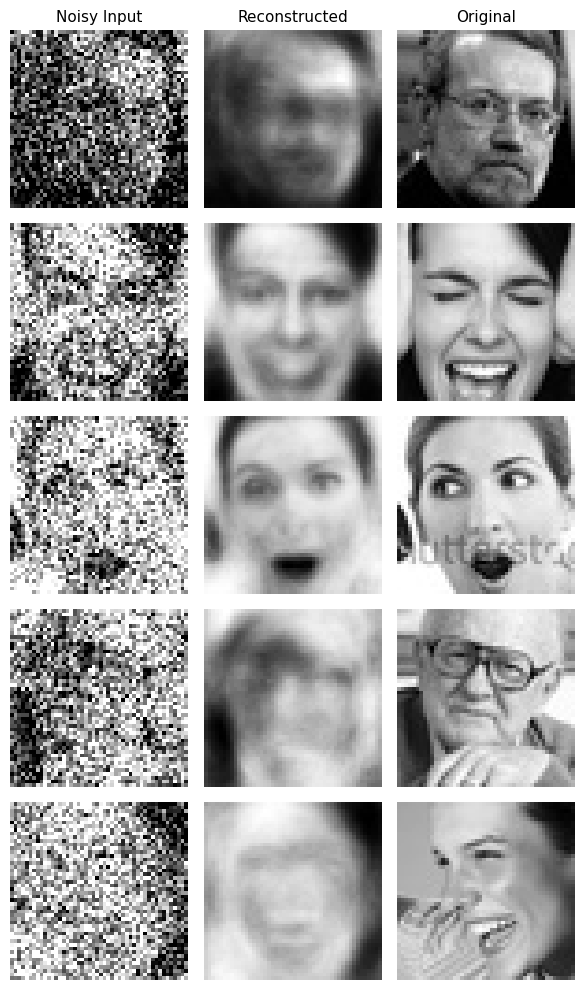

In [25]:
n_examples = 5
fig, axes = plt.subplots(n_examples, 3, figsize=(6, 10))
cols = ["Noisy Input", "Reconstructed", "Original"]

for i in range(n_examples):
    for j, img in enumerate([noisy_np[i], recon_np[i], clean_np[i]]):
        ax = axes[i, j]
        ax.imshow(img, cmap="gray")
        ax.axis("off")
        if i == 0:
            ax.set_title(cols[j], fontsize=11)
plt.tight_layout()
plt.show()